# 3. Fuzzy Logic Decision Fusion

Fusion layer for combining:

1. Isolation Forest anomaly scores.
2. LSTM AutoEncoder reconstruction errors.

The goal is to reduce false positives by requiring stronger agreement between tabular/statistical and temporal/contextual signals.

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.preprocessing import MinMaxScaler

import skfuzzy as fuzz
from skfuzzy import control as ctrl

sns.set_theme(style="darkgrid")

In [75]:
def fuzzy_fusion_layer(
    if_scores,
    lstm_errors,
    y_true,
    decision_threshold=None,
    auto_tune=True,
    lstm_weight=3.5,
    low_bp=0.20,
    high_bp=0.75,
    scale_percentiles=(1, 99),
    plot=True,
):
    """
    Fuse Isolation Forest scores and LSTM AutoEncoder reconstruction errors using
    a vectorized Sugeno-style fuzzy inference system.

    Improvements over the original Mamdani implementation:
      1. Robust percentile scaling (default 1st-99th) instead of plain MinMax.
      2. Membership-function breakpoints tuned to the data.
      3. LSTM_Error is weighted more heavily than the IF score in the rule base.
      4. Fully vectorized with NumPy.
      5. Optional auto_tune: picks the threshold that maximizes F1 on the anomaly class.
      6. CORRECTED: Weights in denominator match weights in numerator for proper scaling.
    """

    if_scores = np.asarray(if_scores, dtype=float).reshape(-1)
    lstm_errors = np.asarray(lstm_errors, dtype=float).reshape(-1)
    y_true = np.asarray(y_true, dtype=float).reshape(-1)

    if not (len(if_scores) == len(lstm_errors) == len(y_true)):
        raise ValueError(
            "if_scores, lstm_errors, and y_true must have the same length. "
            f"Got {len(if_scores)}, {len(lstm_errors)}, and {len(y_true)}."
        )

    clean_df = pd.DataFrame(
        {
            "if_score_raw": if_scores,
            "lstm_error_raw": lstm_errors,
            "y_true": y_true,
        }
    )

    clean_df = clean_df.replace([np.inf, -np.inf], np.nan)
    clean_df["if_score_raw"] = clean_df["if_score_raw"].fillna(clean_df["if_score_raw"].median())
    clean_df["lstm_error_raw"] = clean_df["lstm_error_raw"].fillna(clean_df["lstm_error_raw"].median())
    clean_df["y_true"] = clean_df["y_true"].fillna(0).astype(int)
    clean_df["y_true"] = (clean_df["y_true"] >= 1).astype(int)

    def robust_scale(x, lo_p, hi_p):
        lo, hi = np.percentile(x, [lo_p, hi_p])
        if hi <= lo:
            hi = lo + 1e-9
        return np.clip((x - lo) / (hi - lo), 0.0, 1.0)

    lo_p, hi_p = scale_percentiles
    clean_df["if_score"] = robust_scale(clean_df["if_score_raw"].values, lo_p, hi_p)
    clean_df["lstm_error"] = robust_scale(clean_df["lstm_error_raw"].values, lo_p, hi_p)

    def trimf(x, a, b, c):
        x = np.asarray(x, dtype=float)
        y = np.zeros_like(x)
        if a != b:
            y = np.where((x >= a) & (x < b), (x - a) / (b - a), y)
        y = np.where(x == b, 1.0, y)
        if b != c:
            y = np.where((x > b) & (x <= c), (c - x) / (c - b), y)
        return np.clip(y, 0, 1)

    def fuzzify(x, low_bp, high_bp):
        low = trimf(x, 0.0, 0.0, low_bp)
        med = trimf(x, low_bp * 0.4, 0.5, high_bp)
        high = trimf(x, low_bp, 1.0, 1.0)
        return low, med, high

    if_low, if_med, if_high = fuzzify(clean_df["if_score"].values, low_bp, high_bp)
    l_low, l_med, l_high = fuzzify(clean_df["lstm_error"].values, low_bp, high_bp)

    OUT_LOW, OUT_MED, OUT_HIGH = 0.10, 0.50, 0.95

    w_high_high = if_high * l_high
    w_high_low = if_high * l_low
    w_low_high = if_low * l_high
    w_low_low = if_low * l_low
    w_med_med = if_med * l_med
    w_high_med = if_high * l_med
    w_med_high = if_med * l_high
    w_low_med = if_low * l_med
    w_med_low = if_med * l_low

    numerator = (
        w_high_high * OUT_HIGH
        + w_high_low * OUT_MED
        + w_low_high * OUT_MED * lstm_weight  # LSTM says high -> trust it more
        + w_low_low * OUT_LOW
        + w_med_med * OUT_MED
        + w_high_med * OUT_HIGH
        + w_med_high * OUT_HIGH * lstm_weight # LSTM says high -> trust it more
        + w_low_med * OUT_LOW
        + w_med_low * OUT_LOW
    )
    
    denominator = (
        w_high_high 
        + w_high_low 
        + w_low_high * lstm_weight            # تعديل: إضافة الوزن هنا
        + w_low_low 
        + w_med_med
        + w_high_med 
        + w_med_high * lstm_weight            # تعديل: إضافة الوزن هنا
        + w_low_med 
        + w_med_low
    )
    
    denominator = np.where(denominator == 0, 1e-9, denominator)

    clean_df["final_risk_score"] = np.clip(numerator / denominator, 0.0, 1.0)

    if auto_tune:
        precision, recall, thresholds = precision_recall_curve(
            clean_df["y_true"], clean_df["final_risk_score"]
        )
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        best_idx = int(np.nanargmax(f1))
        decision_threshold = float(thresholds[best_idx]) if best_idx < len(thresholds) else 1.0
        print(f"[auto_tune] Best threshold = {decision_threshold:.4f} "
              f"(F1={f1[best_idx]:.4f}, Precision={precision[best_idx]:.4f}, Recall={recall[best_idx]:.4f})")
    elif decision_threshold is None:
        decision_threshold = 0.5

    clean_df["final_prediction"] = (clean_df["final_risk_score"] >= decision_threshold).astype(int)

    print(f"\nFuzzy fusion classification report (Threshold = {decision_threshold:.4f}):")
    print(
        classification_report(
            clean_df["y_true"],
            clean_df["final_prediction"],
            labels=[0, 1],
            target_names=["Normal", "Anomaly"],
            zero_division=0,
        )
    )

    report_dict = classification_report(
        clean_df["y_true"],
        clean_df["final_prediction"],
        labels=[0, 1],
        target_names=["Normal", "Anomaly"],
        zero_division=0,
        output_dict=True,
    )

    if plot:
        cm = confusion_matrix(clean_df["y_true"], clean_df["final_prediction"], labels=[0, 1])
        plt.figure(figsize=(6, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Purples",
            xticklabels=["Predicted Normal", "Predicted Anomaly"],
            yticklabels=["Actual Normal", "Actual Anomaly"],
        )
        plt.title(f"Fuzzy Fusion Confusion Matrix (Thresh: {decision_threshold:.3f})")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    return clean_df, report_dict

In [76]:
IF_Results = pd.read_csv("IsolationForest_Anomaly_Scores.csv")
LSTM_Results = pd.read_csv("LSTM_Anomaly_Results.csv")

if "Timestamp" in LSTM_Results.columns and "Row_Index" not in LSTM_Results.columns:
    LSTM_Results = LSTM_Results.rename(columns={"Timestamp": "Row_Index"})

Fusion_Data = LSTM_Results.merge(IF_Results, on="Row_Index", how="inner")

print("Isolation Forest rows:", IF_Results.shape)
print("LSTM rows:", LSTM_Results.shape)
print("Merged fusion rows:", Fusion_Data.shape)

Fusion_Data.head()

Isolation Forest rows: (604791, 9)
LSTM rows: (120950, 3)
Merged fusion rows: (120950, 11)


,Row_Index,LSTM_Error,LSTM_Anomaly_Flag,Timestamp,Engine_RPM,Fault_Label,Fault_Type,IF_Anomaly_Score,IF_Anomaly_Score_Raw,IF_Optimized_Anomaly_Flag,IF_Default_Anomaly_Flag
0,483850,0.001330,0,2026-06-06 14:24:10,9.881313e-324,9.881313e-324,Normal,0.059255,-0.283984,0,0
1,483851,0.001341,0,2026-06-06 14:24:11,9.881313e-324,9.881313e-324,Normal,0.049310,-0.288465,0,0
2,483852,0.001284,0,2026-06-06 14:24:12,9.881313e-324,9.881313e-324,Normal,0.075313,-0.276748,0,0
3,483853,0.001263,0,2026-06-06 14:24:13,9.881313e-324,9.881313e-324,Normal,0.062789,-0.282392,0,0
4,483854,0.001245,0,2026-06-06 14:24:14,9.881313e-324,9.881313e-324,Normal,0.050701,-0.287839,0,0


[auto_tune] Best threshold = 0.9347 (F1=0.8151, Precision=0.7046, Recall=0.9669)

Fuzzy fusion classification report (Threshold = 0.9347):
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    108666
     Anomaly       0.70      0.97      0.82     12284

    accuracy                           0.96    120950
   macro avg       0.85      0.96      0.89    120950
weighted avg       0.97      0.96      0.96    120950



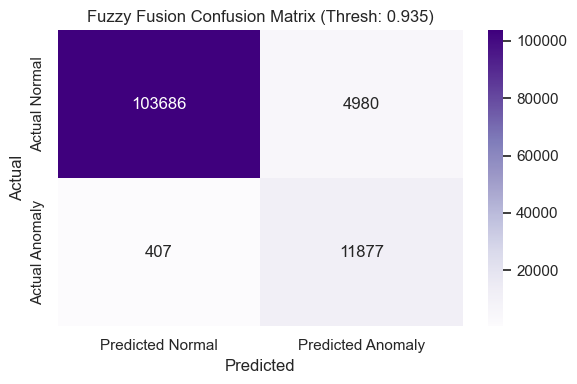

,if_score_raw,lstm_error_raw,y_true,if_score,lstm_error,final_risk_score,final_prediction
0,-0.283984,0.001330,0,0.051936,0.0,0.1,0
1,-0.288465,0.001341,0,0.039534,0.0,0.1,0
2,-0.276748,0.001284,0,0.071960,0.0,0.1,0
3,-0.282392,0.001263,0,0.056342,0.0,0.1,0
4,-0.287839,0.001245,0,0.041269,0.0,0.1,0


In [77]:
if "IF_Anomaly_Score_Raw" in Fusion_Data.columns:
    if_scores = Fusion_Data["IF_Anomaly_Score_Raw"].values
else:
    if_scores = Fusion_Data["IF_Anomaly_Score"].values

lstm_errors = Fusion_Data["LSTM_Error"].values
y_true = Fusion_Data["Fault_Label"].values

Fusion_Output, Fusion_Report = fuzzy_fusion_layer(
    if_scores=if_scores,
    lstm_errors=lstm_errors,
    y_true=y_true,
    auto_tune=True,
    plot=True,
)

Fusion_Output.head()

In [78]:
Final_Fusion_Results = Fusion_Data.reset_index(drop=True).copy()
Final_Fusion_Results["if_score_normalized"] = Fusion_Output["if_score"].values
Final_Fusion_Results["lstm_error_normalized"] = Fusion_Output["lstm_error"].values
Final_Fusion_Results["final_risk_score"] = Fusion_Output["final_risk_score"].values
Final_Fusion_Results["final_prediction"] = Fusion_Output["final_prediction"].values

Final_Fusion_Results.to_csv("Fuzzy_Fusion_Final_Results.csv", index=False)

print("Saved Fuzzy_Fusion_Final_Results.csv")
Final_Fusion_Results.head()

Saved Fuzzy_Fusion_Final_Results.csv


,Row_Index,LSTM_Error,LSTM_Anomaly_Flag,Timestamp,Engine_RPM,Fault_Label,Fault_Type,IF_Anomaly_Score,IF_Anomaly_Score_Raw,IF_Optimized_Anomaly_Flag,IF_Default_Anomaly_Flag,if_score_normalized,lstm_error_normalized,final_risk_score,final_prediction
0,483850,0.001330,0,2026-06-06 14:24:10,9.881313e-324,9.881313e-324,Normal,0.059255,-0.283984,0,0,0.051936,0.0,0.1,0
1,483851,0.001341,0,2026-06-06 14:24:11,9.881313e-324,9.881313e-324,Normal,0.049310,-0.288465,0,0,0.039534,0.0,0.1,0
2,483852,0.001284,0,2026-06-06 14:24:12,9.881313e-324,9.881313e-324,Normal,0.075313,-0.276748,0,0,0.071960,0.0,0.1,0
3,483853,0.001263,0,2026-06-06 14:24:13,9.881313e-324,9.881313e-324,Normal,0.062789,-0.282392,0,0,0.056342,0.0,0.1,0
4,483854,0.001245,0,2026-06-06 14:24:14,9.881313e-324,9.881313e-324,Normal,0.050701,-0.287839,0,0,0.041269,0.0,0.1,0


In [79]:
best_threshold = 0.9347 

import json
config = {"best_threshold": best_threshold, "lstm_weight": 3.5}
with open("model_config.json", "w") as f:
    json.dump(config, f)